# 04 — Final Visualizations

This notebook creates the main visualizations for the descriptive analysis.

The figures focus on:

- Development of AI patent activity
- Leading patent assignees
- Geographic distribution
- Major AI technology areas
- Technology trends
- Competitive positioning
- Relationships between patent characteristics

The visualizations will be used for the final report and dashboard.

In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

ROOT = Path.cwd().parent

PROCESSED_DIR = ROOT / "Data" / "processed"
FIGURES_DIR = ROOT / "Outputs" / "figures"
TABLES_DIR = ROOT / "Outputs" / "tables"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)

DATA_PATH = PROCESSED_DIR / "02_clean_patents.parquet"

df = pd.read_parquet(DATA_PATH)

print("Rows:", f"{len(df):,}")
print("Columns:", df.shape[1])

Rows: 80,566
Columns: 23


In [2]:
patents_by_year = (
    df.groupby("grant_year")
    .size()
    .reset_index(name="patent_count")
)

patents_by_year

,grant_year,patent_count
0,2021,11246
1,2022,15219
2,2023,17597
3,2024,16828
4,2025,15294
5,2026,4382


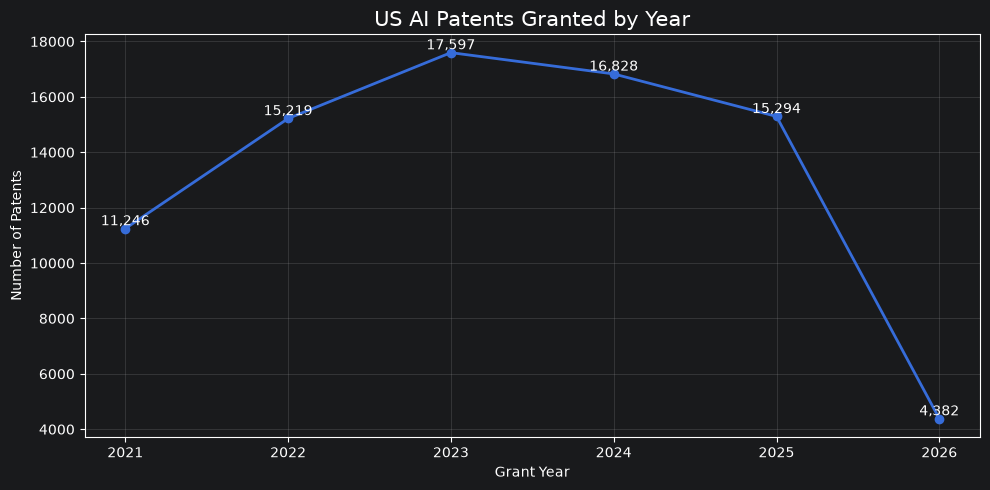

In [3]:
plt.figure(figsize=(10, 5))

plt.plot(
    patents_by_year["grant_year"],
    patents_by_year["patent_count"],
    marker="o",
    linewidth=2
)

for x, y in zip(
    patents_by_year["grant_year"],
    patents_by_year["patent_count"]
):
    plt.text(
        x,
        y,
        f"{y:,}",
        ha="center",
        va="bottom"
    )

plt.title(
    "US AI Patents Granted by Year",
    fontsize=15
)

plt.xlabel("Grant Year")
plt.ylabel("Number of Patents")

plt.grid(alpha=0.25)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "01_patents_by_year.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [4]:
top_assignees = (
    df[df["primary_assignee"] != "Unknown"]
    ["primary_assignee"]
    .value_counts()
    .head(15)
    .sort_values()
)

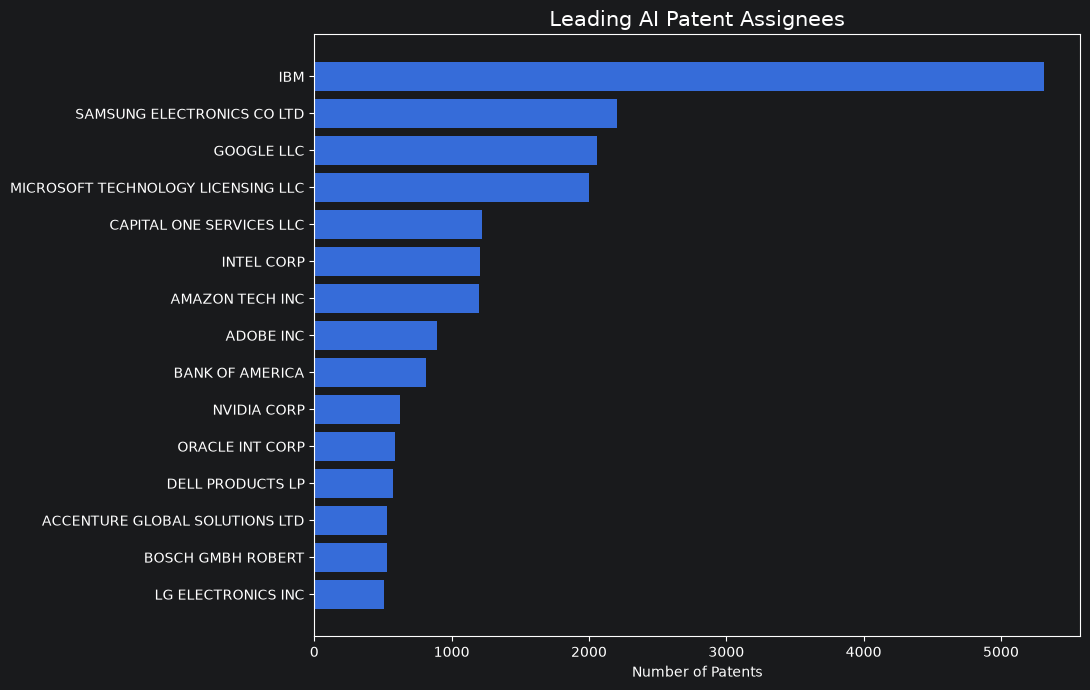

In [5]:
plt.figure(figsize=(11, 7))

plt.barh(
    top_assignees.index,
    top_assignees.values
)

plt.title(
    "Leading AI Patent Assignees",
    fontsize=15
)

plt.xlabel("Number of Patents")
plt.ylabel("")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "02_top_assignees.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [6]:
top_countries = (
    df[df["assignee_country"] != "Unknown"]
    ["assignee_country"]
    .value_counts()
    .head(10)
    .sort_values()
)

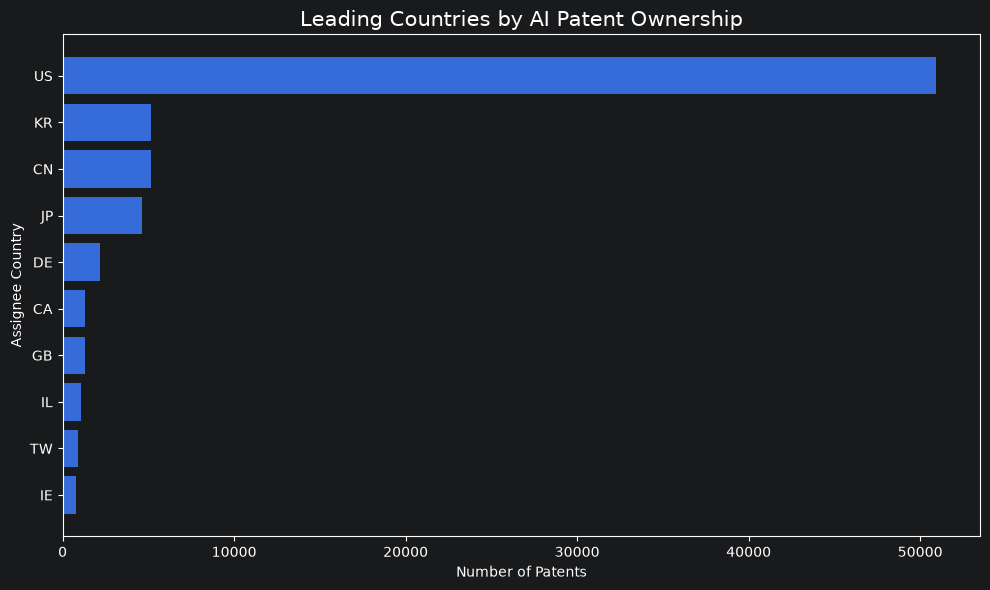

In [7]:
plt.figure(figsize=(10, 6))

plt.barh(
    top_countries.index,
    top_countries.values
)

plt.title(
    "Leading Countries by AI Patent Ownership",
    fontsize=15
)

plt.xlabel("Number of Patents")
plt.ylabel("Assignee Country")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "03_top_countries.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [8]:
technology_counts = (
    df["cpc_group"]
    .value_counts()
    .head(10)
    .sort_values()
)

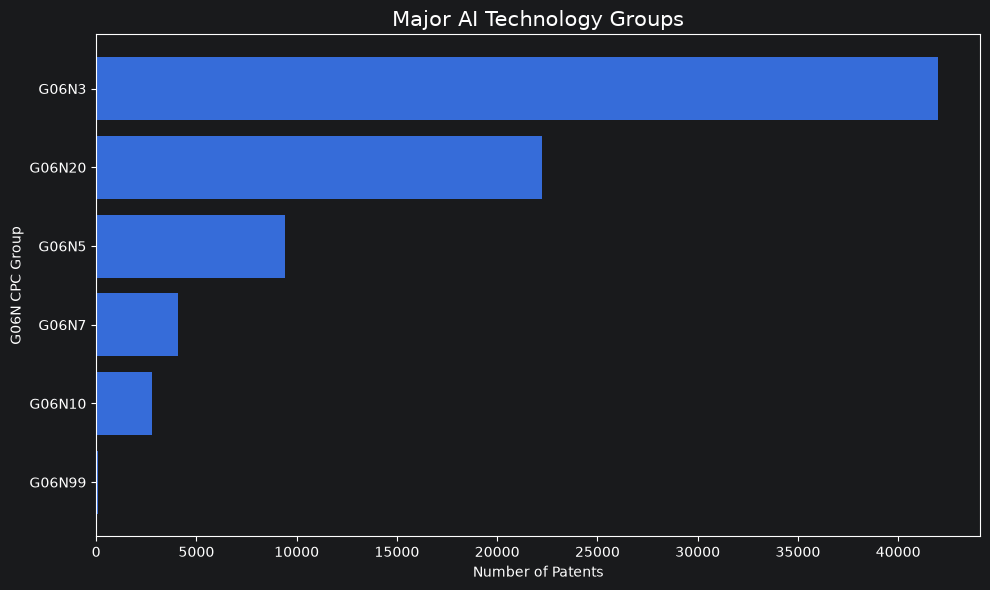

In [9]:
plt.figure(figsize=(10, 6))

plt.barh(
    technology_counts.index,
    technology_counts.values
)

plt.title(
    "Major AI Technology Groups",
    fontsize=15
)

plt.xlabel("Number of Patents")
plt.ylabel("G06N CPC Group")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "04_ai_technology_groups.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [10]:
top_groups = (
    df["cpc_group"]
    .value_counts()
    .head(5)
    .index
)

technology_year = (
    df[df["cpc_group"].isin(top_groups)]
    .groupby(
        ["grant_year", "cpc_group"]
    )
    .size()
    .reset_index(name="patent_count")
)

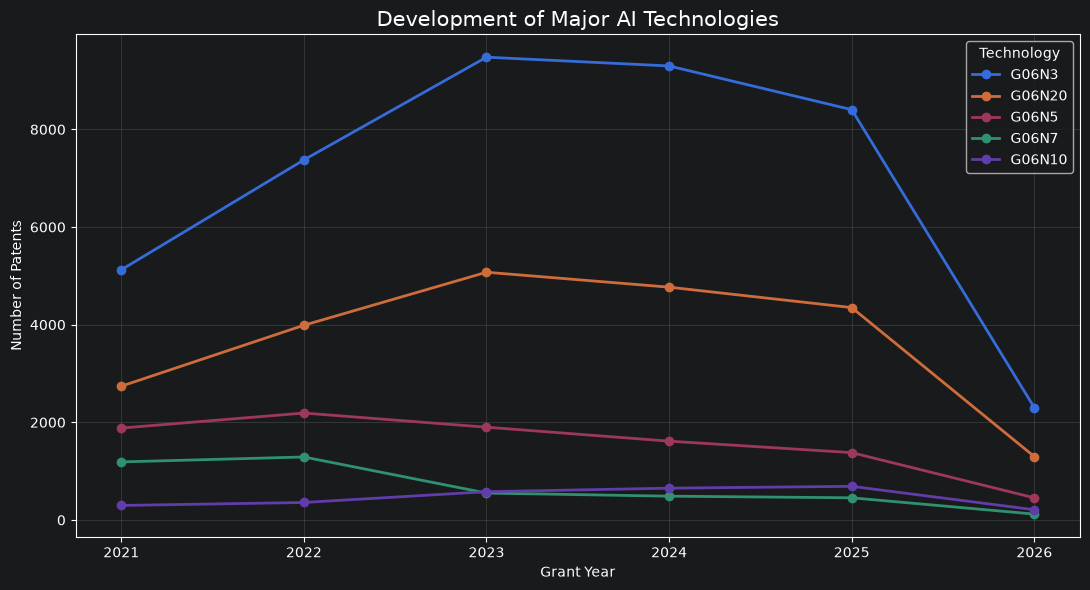

In [11]:
plt.figure(figsize=(11, 6))

for group in top_groups:

    subset = technology_year[
        technology_year["cpc_group"] == group
    ]

    plt.plot(
        subset["grant_year"],
        subset["patent_count"],
        marker="o",
        linewidth=2,
        label=group
    )

plt.title(
    "Development of Major AI Technologies",
    fontsize=15
)

plt.xlabel("Grant Year")
plt.ylabel("Number of Patents")

plt.legend(title="Technology")
plt.grid(alpha=0.25)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "05_technology_trends.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [12]:
top_companies = (
    df[df["primary_assignee"] != "Unknown"]
    ["primary_assignee"]
    .value_counts()
    .head(10)
    .index
)

In [13]:
company_technology = (
    df[
        df["primary_assignee"].isin(top_companies)
        &
        df["cpc_group"].isin(top_groups)
    ]
    .groupby(
        ["primary_assignee", "cpc_group"]
    )
    .size()
    .unstack(fill_value=0)
)

company_technology

cpc_group,G06N10,G06N20,G06N3,G06N5,G06N7
primary_assignee,,,,,
ADOBE INC,0,138,645,63,44
AMAZON TECH INC,50,393,535,152,64
BANK OF AMERICA,41,417,204,130,18
CAPITAL ONE SERVICES LLC,0,499,512,174,36
GOOGLE LLC,211,433,1238,127,52
IBM,487,1419,2061,1032,309
INTEL CORP,81,178,858,60,27
MICROSOFT TECHNOLOGY LICENSING LLC,124,642,883,250,97
NVIDIA CORP,0,47,550,18,10


In [14]:
company_technology_share = (
    company_technology
    .div(
        company_technology.sum(axis=1),
        axis=0
    )
    * 100
)

company_technology_share.round(1)

cpc_group,G06N10,G06N20,G06N3,G06N5,G06N7
primary_assignee,,,,,
ADOBE INC,0.0,15.5,72.5,7.1,4.9
AMAZON TECH INC,4.2,32.9,44.8,12.7,5.4
BANK OF AMERICA,5.1,51.5,25.2,16.0,2.2
CAPITAL ONE SERVICES LLC,0.0,40.9,41.9,14.3,2.9
GOOGLE LLC,10.2,21.0,60.1,6.2,2.5
IBM,9.2,26.7,38.8,19.4,5.8
INTEL CORP,6.7,14.8,71.3,5.0,2.2
MICROSOFT TECHNOLOGY LICENSING LLC,6.2,32.2,44.2,12.5,4.9
NVIDIA CORP,0.0,7.5,88.0,2.9,1.6


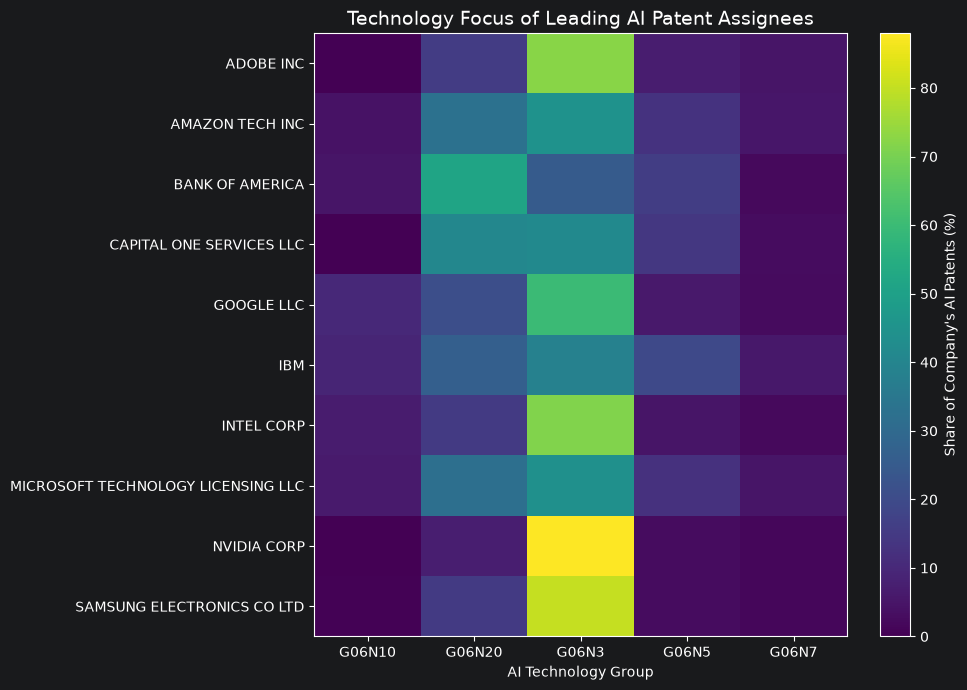

In [15]:
plt.figure(figsize=(10, 7))

plt.imshow(
    company_technology_share,
    aspect="auto"
)

plt.colorbar(
    label="Share of Company's AI Patents (%)"
)

plt.xticks(
    range(len(company_technology_share.columns)),
    company_technology_share.columns
)

plt.yticks(
    range(len(company_technology_share.index)),
    company_technology_share.index
)

plt.title(
    "Technology Focus of Leading AI Patent Assignees",
    fontsize=14
)

plt.xlabel("AI Technology Group")
plt.ylabel("")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "06_company_technology_focus.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [16]:
correlation_columns = [
    "inventor_count",
    "assignee_count",
    "cpc_count",
    "backward_citation_count",
    "abstract_word_count",
    "claims_word_count",
    "filing_to_grant_days"
]

corr = (
    df[correlation_columns]
    .corr()
    .round(2)
)

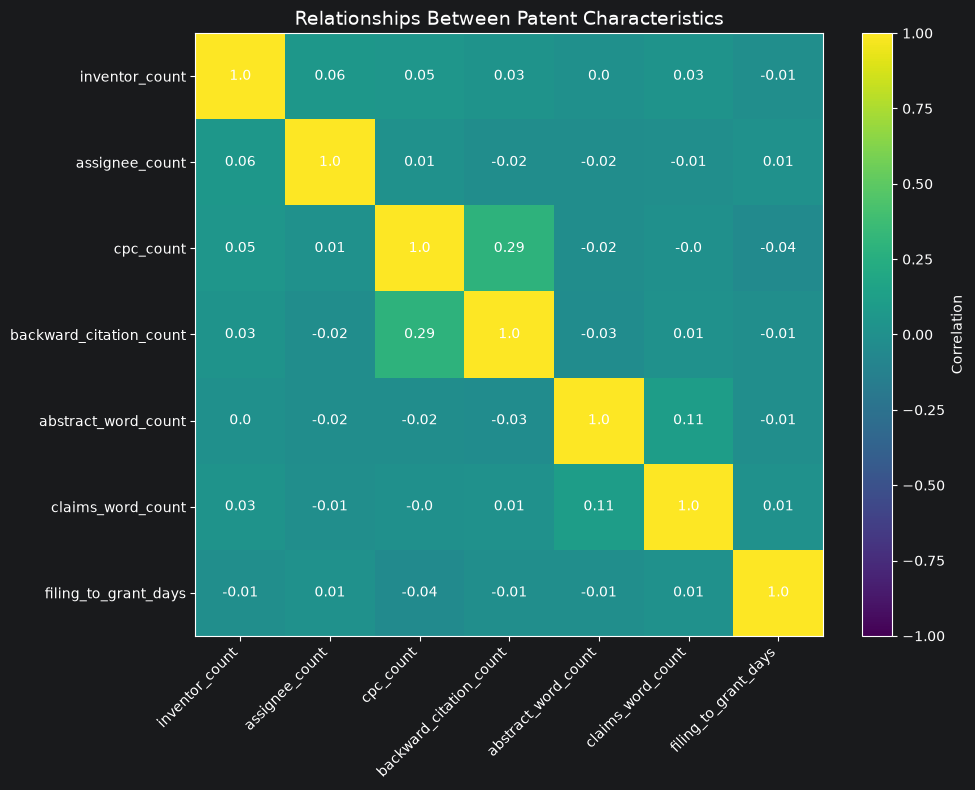

In [17]:
plt.figure(figsize=(10, 8))

plt.imshow(
    corr,
    aspect="auto",
    vmin=-1,
    vmax=1
)

plt.colorbar(label="Correlation")

plt.xticks(
    range(len(correlation_columns)),
    correlation_columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(correlation_columns)),
    correlation_columns
)

for i in range(len(correlation_columns)):
    for j in range(len(correlation_columns)):
        plt.text(
            j,
            i,
            corr.iloc[i, j],
            ha="center",
            va="center"
        )

plt.title(
    "Relationships Between Patent Characteristics",
    fontsize=14
)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "07_correlation_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [18]:
grant_time = (
    df.groupby("cpc_group")
    ["filing_to_grant_days"]
    .median()
    .dropna()
    / 365.25
)

grant_time = (
    grant_time
    .sort_values()
    .tail(10)
)

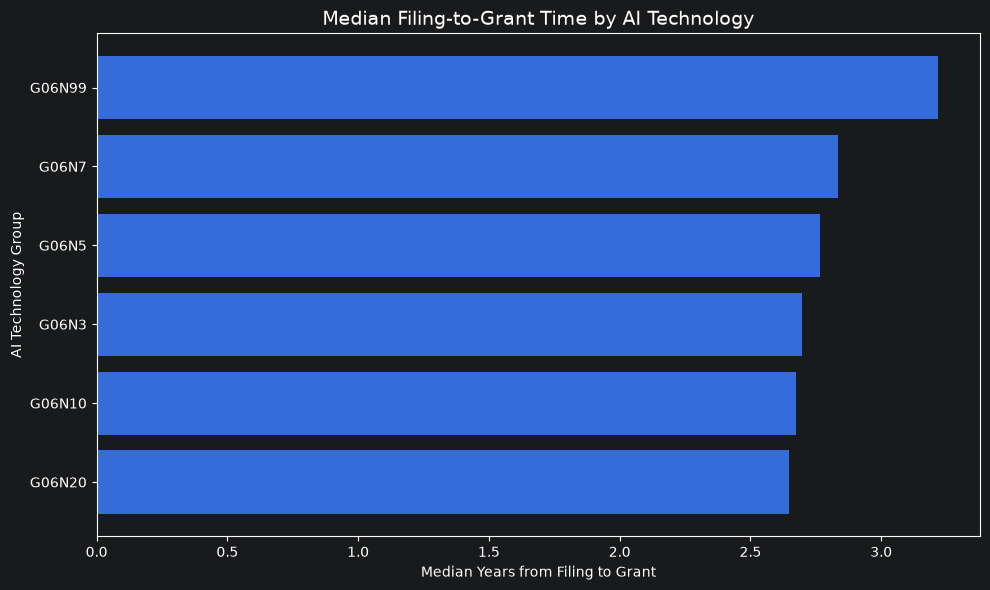

In [19]:
plt.figure(figsize=(10, 6))

plt.barh(
    grant_time.index,
    grant_time.values
)

plt.title(
    "Median Filing-to-Grant Time by AI Technology",
    fontsize=14
)

plt.xlabel("Median Years from Filing to Grant")
plt.ylabel("AI Technology Group")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "08_grant_time_by_technology.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [20]:
figure_files = sorted(
    FIGURES_DIR.glob("*.png")
)

print(
    "Figures created:",
    len(figure_files)
)

for file in figure_files:
    print(file.name)

Figures created: 8
01_patents_by_year.png
02_top_assignees.png
03_top_countries.png
04_ai_technology_groups.png
05_technology_trends.png
06_company_technology_focus.png
07_correlation_matrix.png
08_grant_time_by_technology.png
